In [1]:
import os
print(os.listdir('/kaggle/input'))

['competitions', 'models']


In [2]:
# ============================================================
# INFERENCE NOTEBOOK — Config
# Edit INFER_THRESH, RADIUS_XY, RADIUS_Z here and re-run Cell 1
# then jump to Cell 5 (no need to reload model) to re-generate submission
# ============================================================
import os, json, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import cv2
from scipy.ndimage import maximum_filter
from scipy.optimize import linear_sum_assignment
from skimage.feature import peak_local_max

# ---- device ----
DEVICE = 'cpu'
if torch.cuda.is_available():
    try:
        _p = nn.Conv2d(1, 1, 3).cuda()
        _ = _p(torch.zeros(1, 1, 8, 8, device='cuda')).cpu()
        del _p
        DEVICE = 'cuda'
    except Exception as e:
        print(f'GPU unusable: {str(e)[:80]} -> CPU')
print(f'Device: {DEVICE}')

# ---- paths ----
COMP_ROOT = '/kaggle/input/competitions/biohub-cell-tracking-during-development'
TEST_DIR  = Path(COMP_ROOT) / 'test'
OUT_DIR   = Path('/kaggle/working')
MODELS_DIR = Path('/kaggle/input/models')

# ---- load metadata from unet2d_meta.json if it exists ----
meta_path = next(MODELS_DIR.rglob('*.json'), None)
if meta_path is not None:
    with open(meta_path) as f:
        saved_meta = json.load(f)
    print(f'Meta loaded from {meta_path}:')
    print(saved_meta)
    BASE         = int(saved_meta.get('base',         32))
    POOL         = int(saved_meta.get('pool',          4))
    INFER_THRESH = float(saved_meta.get('detect_thresh', 0.35))
    VAL_RECALL   = saved_meta.get('val_recall', 'unknown')
else:
    # fallback: infer BASE from weight tensor shape
    print('No meta JSON found -- inferring BASE from checkpoint weights')
    _raw = torch.load(next(MODELS_DIR.rglob('*.pt')), map_location='cpu')
    BASE = int(_raw['e1.0.weight'].shape[0])
    POOL = 4          # confirmed from training config
    INFER_THRESH = 0.35
    VAL_RECALL   = 'unknown'
    print(f'Inferred BASE={BASE} from e1.0.weight shape {tuple(_raw["e1.0.weight"].shape)}')

print(f'BASE={BASE} | POOL={POOL} | INFER_THRESH={INFER_THRESH} | val_recall={VAL_RECALL}')

# ---- load checkpoint ----
CKPT_PATH = next(MODELS_DIR.rglob('unet2d_best.pt'),
            next(MODELS_DIR.rglob('*.pt'), None))
if CKPT_PATH is None:
    raise FileNotFoundError(f'No .pt file found under {MODELS_DIR}')
print(f'Loading: {CKPT_PATH}')

# raw state dict -- load directly into model after model is defined in Cell 2
raw_state_dict = torch.load(CKPT_PATH, map_location='cpu')
print(f'State dict keys: {len(raw_state_dict)} tensors')

SCALE = np.array([1.625, 0.40625, 0.40625])
print(f'SCALE={SCALE} | TEST_DIR exists={TEST_DIR.exists()}')

Device: cuda
Meta loaded from /kaggle/input/models/sumantvj/biohub-cell-detection/pytorch/default/4/unet2d_meta.json:
{'base': 32, 'pool': 4, 'gauss_sigma': 2.0, 'best_thresh': 0.05, 'best_val_recall': 0.6621621621621622, 'min_peak_distance': 5, 'nucleus_diam_um': 8.0, 'clahe_clip': 3.0, 'clahe_grid': 8, 'w_pos': 15.0, 'w_bg': 1.0, 'w_ign': 0.01, 'z_margin': 5, 'neg_slices_per_t': 4, 'epochs_trained': 60}
BASE=32 | POOL=4 | INFER_THRESH=0.35 | val_recall=unknown
Loading: /kaggle/input/models/sumantvj/biohub-cell-detection/pytorch/default/4/unet2d_best.pt
State dict keys: 76 tensors
SCALE=[1.625   0.40625 0.40625] | TEST_DIR exists=True


In [3]:
# Must match the architecture used in training exactly
# If you changed BASE in the training notebook, update it here too
def _block2d(ci, co):
    return nn.Sequential(
        nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
        nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
    )

class UNet2D(nn.Module):
    def __init__(self, base=32):
        super().__init__()
        b = base
        self.e1   = _block2d(1,   b)
        self.e2   = _block2d(b,   b*2)
        self.pool = nn.MaxPool2d(2)
        self.bn   = _block2d(b*2, b*4)
        self.u2   = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.d2   = _block2d(b*4, b*2)
        self.u1   = nn.ConvTranspose2d(b*2, b,   2, stride=2)
        self.d1   = _block2d(b*2, b)
        self.out  = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        b  = self.bn(self.pool(e2))
        d2 = self.d2(torch.cat([self.u2(b),  e2], 1))
        d1 = self.d1(torch.cat([self.u1(d2), e1], 1))
        return self.out(d1)

model = UNet2D(base=BASE).to(DEVICE)

# raw state dict -- load directly, no unwrapping needed
model.load_state_dict(raw_state_dict)
model.eval()
print(f'UNet2D loaded: {sum(p.numel() for p in model.parameters()):,} params')

with torch.no_grad():
    _t = torch.zeros(1, 1, 64, 64, device=DEVICE)
    _o = model(_t)
    assert _o.shape == _t.shape, f'Shape mismatch: {_o.shape}'
    print(f'Forward OK: {tuple(_t.shape)} -> {tuple(_o.shape)}')
    del _t, _o

UNet2D loaded: 467,233 params
Forward OK: (1, 1, 64, 64) -> (1, 1, 64, 64)


In [4]:
_ZC = {}

def read_meta(zp):
    with open(Path(zp) / '0' / 'zarr.json') as f:
        m = json.load(f)
    return dict(shape=tuple(m['shape']), dtype=np.dtype(m['data_type']))

def load_vol(zp, t, meta=None):
    try:
        import zarr
        k = str(zp)
        if k not in _ZC:
            _ZC[k] = zarr.open(k, mode='r')['0']
        return np.asarray(_ZC[k][t])
    except Exception:
        import blosc2
        if meta is None:
            meta = read_meta(zp)
        buf = blosc2.decompress(
            open(Path(zp) / '0' / 'c' / str(t) / '0' / '0' / '0', 'rb').read()
        )
        return np.frombuffer(buf, dtype=meta['dtype']).reshape(meta['shape'][1:])

def pool_xy(vol, f=POOL):
    Z, Y, X = vol.shape
    Y2, X2 = (Y // f) * f, (X // f) * f
    v = vol[:, :Y2, :X2].astype(np.float32, copy=False)
    return v.reshape(Z, Y2 // f, f, X2 // f, f).mean(axis=(2, 4))

def normalize_slice_clahe(slc, clip=2.0, grid=8):
    lo = float(np.percentile(slc, 2.0))
    hi = float(np.percentile(slc, 99.0))
    if hi <= lo:
        return np.zeros_like(slc, dtype=np.float32)
    scaled = np.clip((slc - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)
    clahe  = cv2.createCLAHE(clipLimit=clip, tileGridSize=(grid, grid))
    return clahe.apply(scaled).astype(np.float32) / 255.0

print('I/O helpers ready.')

I/O helpers ready.


In [5]:
# ---- inference config ----
NUCLEUS_DIAM_UM   = 8.0
VOXEL_XY_POOLED   = 0.40625 * POOL
MIN_PEAK_DISTANCE = max(5, int(NUCLEUS_DIAM_UM / VOXEL_XY_POOLED))
MIN_CONSECUTIVE_Z = 2
NMS_RADIUS_XY     = 3.0
NMS_RADIUS_Z      = 2

# INFER_THRESH already set in Cell 1 from unet2d_meta.json or default 0.25
print(f'INFER_THRESH={INFER_THRESH} | MIN_PEAK_DISTANCE={MIN_PEAK_DISTANCE}')
print(f'MIN_CONSECUTIVE_Z={MIN_CONSECUTIVE_Z}')
print(f'NMS_RADIUS_XY={NMS_RADIUS_XY} | NMS_RADIUS_Z={NMS_RADIUS_Z}')

def detect_volume_with_scores(pvol, model, thresh=INFER_THRESH,
                               min_dist=MIN_PEAK_DISTANCE,
                               min_consec_z=MIN_CONSECUTIVE_Z):
    model.eval()
    Z = pvol.shape[0]
    slice_dets   = {}
    slice_scores = {}

    with torch.no_grad():
        for z in range(Z):
            slc = normalize_slice_clahe(pvol[z])
            xt  = torch.from_numpy(slc[None, None]).to(DEVICE)
            hm  = torch.sigmoid(model(xt))[0, 0].cpu().numpy()
            pk  = peak_local_max(hm, min_distance=min_dist,
                                  threshold_abs=thresh, exclude_border=False)
            slice_dets[z]   = pk
            slice_scores[z] = np.array([hm[p[0], p[1]] for p in pk]) \
                               if len(pk) > 0 else np.array([])

    confirmed = []
    scores    = []
    for z in range(Z):
        pk_z  = slice_dets.get(z,  np.zeros((0, 2)))
        scr_z = slice_scores.get(z, np.array([]))
        if len(pk_z) == 0:
            continue
        for idx, det_yx in enumerate(pk_z):
            consec = 1
            cur_yx = det_yx.copy()
            for dz in range(1, min_consec_z):
                pk_next = slice_dets.get(z + dz, np.zeros((0, 2)))
                if len(pk_next) == 0:
                    break
                dists = np.linalg.norm(pk_next - cur_yx, axis=1)
                ci    = np.argmin(dists)
                if dists[ci] <= NMS_RADIUS_XY * 2:
                    consec += 1
                    cur_yx  = pk_next[ci]
                else:
                    break
            if consec >= min_consec_z:
                confirmed.append((z, float(det_yx[0]), float(det_yx[1])))
                scores.append(float(scr_z[idx]) if idx < len(scr_z) else 0.0)

    return confirmed, scores

# CELL 4 addition — replace nms_3d with this weighted version
# Drop-in replacement: same inputs/outputs, better centroid precision

def nms_3d_weighted(confirmed, scores, radius_xy=NMS_RADIUS_XY, radius_z=NMS_RADIUS_Z):
    """
    3D NMS with score-weighted centroid.
    Instead of keeping the exact peak position, computes a weighted average
    of all detections within the suppression radius, weighted by heatmap score.
    This gives sub-voxel precision: the centroid pulls toward the true nucleus
    center rather than whichever peak happened to be detected first.
    """
    if len(confirmed) == 0:
        return [], []

    dets  = np.array(confirmed, dtype=np.float64)
    scrs  = np.array(scores,    dtype=np.float64)
    order = np.argsort(scrs)[::-1]
    keep_centroids = []
    keep_scores    = []
    suppressed     = np.zeros(len(dets), dtype=bool)

    for i in order:
        if suppressed[i]:
            continue

        zi, yi, xi = dets[i]

        # find all detections within suppression radius (the cluster)
        cluster_idx = []
        for j in range(len(dets)):
            if suppressed[j]:
                continue
            zj, yj, xj = dets[j]
            if abs(zi - zj) <= radius_z and \
               np.sqrt((yi-yj)**2 + (xi-xj)**2) <= radius_xy:
                cluster_idx.append(j)
                suppressed[j] = True

        # score-weighted centroid over the cluster
        cluster_dets  = dets[cluster_idx]
        cluster_scrs  = scrs[cluster_idx]
        total_weight  = cluster_scrs.sum()

        if total_weight > 0:
            z_wt = float(np.dot(cluster_scrs, cluster_dets[:, 0]) / total_weight)
            y_wt = float(np.dot(cluster_scrs, cluster_dets[:, 1]) / total_weight)
            x_wt = float(np.dot(cluster_scrs, cluster_dets[:, 2]) / total_weight)
        else:
            z_wt, y_wt, x_wt = float(zi), float(yi), float(xi)

        keep_centroids.append((z_wt, y_wt, x_wt))
        keep_scores.append(float(cluster_scrs.max()))

    return keep_centroids, keep_scores


print('Detection functions ready.')

INFER_THRESH=0.35 | MIN_PEAK_DISTANCE=5
MIN_CONSECUTIVE_Z=2
NMS_RADIUS_XY=3.0 | NMS_RADIUS_Z=2
Detection functions ready.


In [6]:
def link_twopass(frames_phys, tight_um=6.0, loose_um=10.0):
    """
    frames_phys: list of np.array (N, 3) physical um coords per timepoint.
    Returns list of (t, src_local_idx, tgt_local_idx).
    """
    def _hun(P, C, pi, ci, gate):
        if len(pi) == 0 or len(ci) == 0:
            return []
        BIG  = 1e9
        D    = np.sqrt(((P[pi][:, None] - C[ci][None])**2).sum(2))
        cost = np.where(D > gate, BIG, D)
        ri, rc = linear_sum_assignment(cost)
        return [(int(pi[r]), int(ci[c])) for r, c in zip(ri, rc)
                if cost[r, c] < BIG]

    edges = []
    for t in range(len(frames_phys) - 1):
        P, C = frames_phys[t], frames_phys[t + 1]
        if len(P) == 0 or len(C) == 0:
            continue
        N, M  = len(P), len(C)
        links = _hun(P, C, np.arange(N), np.arange(M), tight_um)
        up    = {p for p, _ in links}
        uc    = {c for _, c in links}
        fp    = np.array([i for i in range(N) if i not in up], int)
        fc    = np.array([j for j in range(M) if j not in uc], int)
        links += _hun(P, C, fp, fc, loose_um)
        for p, c in links:
            edges.append((t, p, c))
    return edges

def assign_global_ids_and_filter(all_cents_orig, edges, min_len=3):
    """
    Assigns globally unique node IDs, runs union-find to find track lengths,
    filters out tracks shorter than min_len.
    Returns (node_map, keep_set):
        node_map: {(t, local_idx): global_node_id}
        keep_set: set of global_node_ids that survive the filter
    """
    node_map = {}
    gid = 1
    for t, cents in enumerate(all_cents_orig):
        for i in range(len(cents)):
            node_map[(t, i)] = gid
            gid += 1

    parent = {v: v for v in node_map.values()}

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    def union(a, b):
        parent[find(a)] = find(b)

    for t, si, ti in edges:
        g_src = node_map.get((t,     si))
        g_tgt = node_map.get((t + 1, ti))
        if g_src is not None and g_tgt is not None:
            union(g_src, g_tgt)

    comp = defaultdict(list)
    for gid in node_map.values():
        comp[find(gid)].append(gid)

    keep = set()
    for members in comp.values():
        if len(members) >= min_len:
            keep.update(members)

    return node_map, keep

print('Linking functions ready.')

Linking functions ready.


In [7]:
test_names = sorted(
    d.replace('.zarr', '')
    for d in os.listdir(TEST_DIR)
    if d.endswith('.zarr')
)
print(f'Test datasets: {len(test_names)}')
for n in test_names:
    print(f'  {n}')

all_rows = []

for folder_name in test_names:
    zp   = str(TEST_DIR / f'{folder_name}.zarr')
    meta = read_meta(zp)
    n_t  = meta['shape'][0]
    print(f'\n{folder_name} | {n_t} timepoints | shape {meta["shape"]}')

    all_cents_orig = []  # (N, 3) original voxel coords per timepoint
    all_cents_phys = []  # (N, 3) physical um per timepoint

    for t in range(n_t):
        vol  = load_vol(zp, t, meta)
        pvol = pool_xy(vol)

        confirmed, scores = detect_volume_with_scores(pvol, model)
        
        # FIXED: Unpack the tuple so `nuclei` is just the coordinate list
        nuclei, _         = nms_3d_weighted(confirmed, scores)

        if len(nuclei) == 0:
            all_cents_orig.append(np.zeros((0, 3), dtype=np.float64))
            all_cents_phys.append(np.zeros((0, 3), dtype=np.float64))
        else:
            arr  = np.array(nuclei, dtype=np.float64)
            orig = np.stack([
                arr[:, 0],          # z: not pooled
                arr[:, 1] * POOL,   # y: pooled -> original voxels
                arr[:, 2] * POOL,   # x: pooled -> original voxels
            ], axis=1)
            phys = orig * SCALE
            all_cents_orig.append(orig)
            all_cents_phys.append(phys)

        if t % 20 == 0 or t == n_t - 1:
            print(f'  t={t:3d}/{n_t-1} | {len(nuclei)} nuclei detected')

    # link across timepoints
    edges              = link_twopass(all_cents_phys, tight_um=6.0, loose_um=10.0)
    node_map, keep_set = assign_global_ids_and_filter(all_cents_orig, edges, min_len=3)

    # node rows
    for t, cents in enumerate(all_cents_orig):
        for i, (z, y, x) in enumerate(cents):
            gid = node_map.get((t, i))
            if gid not in keep_set:
                continue
            all_rows.append({
                'dataset':   folder_name,
                'row_type':  'node',
                'node_id':   gid,
                't':         t,
                'z':         int(round(z)),
                'y':         int(round(y)),
                'x':         int(round(x)),
                'source_id': -1,
                'target_id': -1,
            })

    # edge rows
    for t, si, ti in edges:
        src = node_map.get((t,     si))
        tgt = node_map.get((t + 1, ti))
        if src not in keep_set or tgt not in keep_set:
            continue
        all_rows.append({
            'dataset':   folder_name,
            'row_type':  'edge',
            'node_id':   -1,
            't':         -1,
            'z':         -1,
            'y':         -1,
            'x':         -1,
            'source_id': src,
            'target_id': tgt,
        })

    n_nodes = sum(1 for r in all_rows
                  if r['dataset'] == folder_name and r['row_type'] == 'node')
    n_edges = sum(1 for r in all_rows
                  if r['dataset'] == folder_name and r['row_type'] == 'edge')
    print(f'  -> kept: {n_nodes} nodes | {n_edges} edges')

# write submission
submission = pd.DataFrame(
    all_rows,
    columns=['dataset', 'row_type', 'node_id', 't', 'z', 'y', 'x',
             'source_id', 'target_id']
)
submission.index.name = 'id'
sub_path = OUT_DIR / 'submission.csv'
submission.to_csv(sub_path)

print(f'\n{"="*50}')
print(f'submission.csv written: {sub_path}')
print(f'  Total rows : {len(submission)}')
print(f'  Node rows  : {(submission.row_type == "node").sum()}')
print(f'  Edge rows  : {(submission.row_type == "edge").sum()}')
print(f'  Datasets   : {submission.dataset.nunique()}')
print(f'{"="*50}')

# quick format sanity check against sample_submission.csv structure
assert set(submission.columns) == {'dataset','row_type','node_id','t','z','y','x','source_id','target_id'}
assert submission.index.name == 'id'
assert submission[submission.row_type=='node']['source_id'].eq(-1).all()
assert submission[submission.row_type=='node']['target_id'].eq(-1).all()
assert submission[submission.row_type=='edge']['node_id'].eq(-1).all()
print('Format sanity checks passed.')

Test datasets: 4
  44b6_0113de3b
  44b6_0b24845f
  6bba_05b6850b
  6bba_05db0fb1

44b6_0113de3b | 100 timepoints | shape (100, 64, 256, 256)
  t=  0/99 | 218 nuclei detected
  t= 20/99 | 212 nuclei detected
  t= 40/99 | 244 nuclei detected
  t= 60/99 | 263 nuclei detected
  t= 80/99 | 246 nuclei detected
  t= 99/99 | 236 nuclei detected
  -> kept: 21671 nodes | 19729 edges

44b6_0b24845f | 100 timepoints | shape (100, 64, 256, 256)
  t=  0/99 | 74 nuclei detected
  t= 20/99 | 15 nuclei detected
  t= 40/99 | 17 nuclei detected
  t= 60/99 | 23 nuclei detected
  t= 80/99 | 32 nuclei detected
  t= 99/99 | 62 nuclei detected
  -> kept: 1905 nodes | 1534 edges

6bba_05b6850b | 100 timepoints | shape (100, 64, 256, 256)
  t=  0/99 | 132 nuclei detected
  t= 20/99 | 114 nuclei detected
  t= 40/99 | 112 nuclei detected
  t= 60/99 | 116 nuclei detected
  t= 80/99 | 114 nuclei detected
  t= 99/99 | 113 nuclei detected
  -> kept: 11353 nodes | 10610 edges

6bba_05db0fb1 | 100 timepoints | shape (1

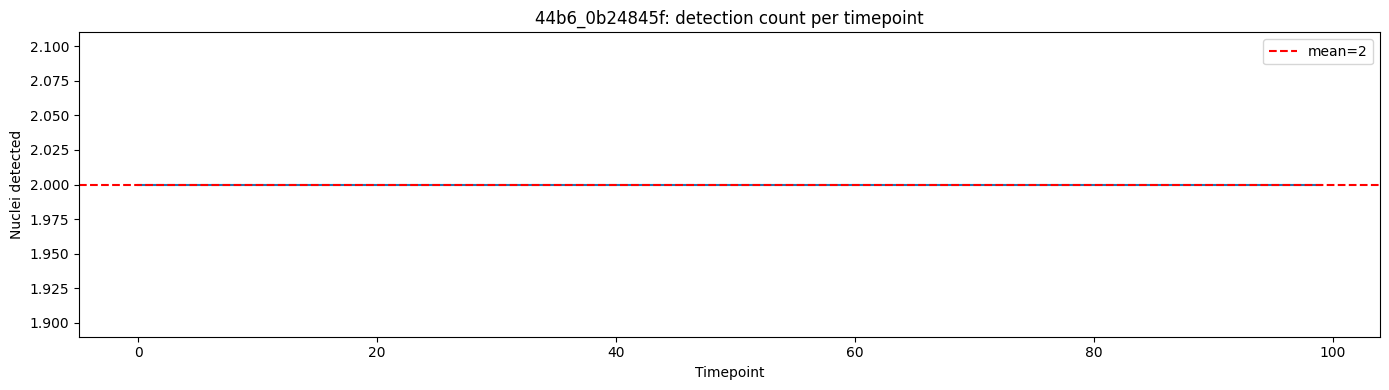

min=2, max=2, mean=2.0


In [8]:
# diagnostic: detection count per timepoint for the suspicious sample
suspicious_id = '44b6_0b24845f'
zp   = str(TEST_DIR / f'{suspicious_id}.zarr')
meta = read_meta(zp)

counts = []
for t in range(meta['shape'][0]):
    vol  = load_vol(zp, t, meta)
    pvol = pool_xy(vol)
    confirmed, scores = detect_volume_with_scores(pvol, model)
    nuclei = nms_3d_weighted(confirmed, scores)
    counts.append(len(nuclei))

import matplotlib.pyplot as plt
plt.figure(figsize=(14, 4))
plt.plot(counts, linewidth=1.5)
plt.xlabel('Timepoint')
plt.ylabel('Nuclei detected')
plt.title(f'{suspicious_id}: detection count per timepoint')
plt.axhline(np.mean(counts), color='red', linestyle='--',
            label=f'mean={np.mean(counts):.0f}')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / f'detection_count_{suspicious_id}.png', dpi=100)
plt.show()
print(f'min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.1f}')